In [49]:
import duckdb
import pandas as pd
from pathlib import Path
import diskcache
from itertools import chain
from collections import Counter

import igraph as ig
import matplotlib.pyplot as plt
import seaborn.objects as so
import seaborn as sns

from utils.pandas_setup import pandas_setup
pandas_setup()

import pyalex
from pyalex import Works, Authors, Sources, Institutions, Topics, Publishers, Funders
pyalex.config.email = "Lawrence.Cram@anu.edu.au"
pyalex.config.max_retries = 0
pyalex.config.retry_backoff_factor = 0.1
pyalex.config.retry_http_codes = [429, 500, 503]

MY_DATA_PATH = Path('../DATA/')
MY_DATABASE_FILE = Path(MY_DATA_PATH / 'econ.duckdb')
MY_CACHE_FILE = Path('/home/lc/m/.cache/econommicsbusiness/cache.db')
DATAFILES_PATH = Path('../DATAFILES')

In [50]:
class SetUp:

    def __init__(self):
        self._setup_db()
        self._setup_cache()
        return
    
    def _setup_db(self):
        self.db = duckdb.connect(MY_DATABASE_FILE)
        self.db.sql("ATTACH IF NOT EXISTS ':memory:'")
        self.db.sql(""" SET memory_limit = '56GB';
                        SET threads = 6;
                        SET preserve_insertion_order = false;
                        SET order_by_non_integer_literal=true;
                        SET enable_progress_bar = true;
                        SET temp_directory = '/home/lc/m/.tmp';
                    """)
        self.db.sql("SHOW ALL TABLES").show()
        return
    
    def _setup_cache(self):
        self.cache = diskcache.Cache(MY_CACHE_FILE, size_limit=16_000_000_000)
        print(f'{self.cache.check() = }')
        print(f'{self.cache.volume() = }')
        return
    
    def name_of_global_obj(self, obj=None):
        for objname, oid in globals().items():
            if oid is obj:
                return objname
            

In [51]:
class CoauthorshipNetwork(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def build_authorship_network(self):
        # get works from a few small, top  journals
        source_list = 'https://openalex.org/S2764736659 https://openalex.org/S7397502'
        sql = f"""
                CREATE OR REPLACE TABLE memory.network AS 
                    SELECT replace(source_id, 'https://openalex.org/', '') AS source_id,
                            -- any_value(source_name),
                            replace(institution_id, 'https://openalex.org/', '') AS institution_id,
                            -- any_value(institution_name)
                            count(work_id) AS weight,
                        FROM works w
                        LEFT JOIN authorships a
                            USING (work_id) 
                            WHERE contains('{source_list}', w.source_id) = true 
                                    AND author_name NOT NULL
                                    AND work_id NOT NULL
                        GROUP BY source_id, institution_id, source_name, institution_name
                        ORDER BY weight DESC, source_name, institution_name
            """
        self.db.sql(sql)
        self.db.sql("SELECT * FROM memory.network").show()
        self.db.sql("COPY memory.network TO '../DATA/NETWORK_DATA/trial.csv' (HEADER false, DELIMITER '\t')")
        return
    
    def extract_graph(self):
        self.g = ig.Graph.Read_Ncol('../DATA/NETWORK_DATA/trial.csv', names=True)
        print(self.g.get_edgelist())
        print(self.g.es["weight"])
        print(self.g.vs["name"])
        return
    
    def pagerank(self):
        ranks = self.g.pagerank()
        print(ranks)
        return


### This class constructs the pageRank for sources linked by citation counts

-  build the edge list of journal (citer) -> journal (cited)  
-  construct an iGraph from the edge list  
-  run pageRank  
-  for each author, calculate the number of ciations and the number of citations weighted by the pageRank of the citing journal



In [52]:
class CitationNetwork(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def journal_edge_list(self):
        # SQL code to assemble the source-source edge list with the count of work-work citations as weights
        sql = """
        CREATE OR REPLACE TABLE econ.source_citations AS
        SELECT --sub.work_id,
                --sub.cited_id,
                sub.source_id AS citer_source,
                ww.source_id AS cited_source,
                count(ww.work_id) AS weights,
        FROM
            (SELECT w.work_id,
                    w.source_id,
                    w.cited_by_count,
                    unnest(c.referenced_works) AS cited_id
            FROM works w
            LEFT JOIN cited c
            USING (work_id)
            WHERE w.source_id NOT NULL) sub 
            
        LEFT JOIN works ww
            ON ww.work_id = sub.cited_id
            WHERE ww.source_id NOT NULL
        GROUP BY citer_source, cited_source
        ORDER BY weights DESC
        """
        self.db.sql(sql)
        return

    def construct_graph(self):
        df_edges = self.db.sql("SELECT * FROM econ.source_citations").df()
        drop_citations = 0
        df_edges = df_edges[df_edges.weights >= drop_citations].sort_values('weights', ascending=False).reset_index(drop=True)
        print(f'*** DROP EDGES WITH FEWER THAN {drop_citations} CITATIONS {df_edges.shape = }\n{df_edges.head()}')
        self.g = ig.Graph.DataFrame(df_edges, directed=True, use_vids=False)
        print(self.g.get_edgelist())
        summary = ig.summary(self.g, verbosity=1, width=256, edge_list_format='auto', max_rows=99, print_graph_attributes=True, 
                                          print_vertex_attributes=True, print_edge_attributes=True, full=False)
        print(f'*** SUMMARY OF self.g\n{summary}')
        return
    
    def run_pagerank(self):
        print('pageRank')
        ranks = self.g.pagerank(weights='weights', implementation='power')
        print(f'>> CHECK pageRank  - should sum to unity {sum(ranks) = }')
        rank_max = max(ranks)
        ranks = [10.*r/rank_max for r in ranks]
        self.pagerank = pd.DataFrame(zip(ranks, self.g.vs["name"], self.g.strength(mode='in', loops=True, weights='weights')), columns=['pageRank','citer', 'cite_count']).sort_values('pageRank', ascending=False)
        df = self.pagerank
        self.db.sql("CREATE OR REPLACE TABLE econ.pageRank AS SELECT * FROM df")
        return
    
    def report_pagerank(self):
        for sort in ['pageRank', 'cite_count']:
            df = self.pagerank.sort_values(sort, ascending=False).reset_index(drop=True)        
            print(f'{df.shape = }\n{df.head(8)}')
            print(f'\n{df.tail(8)}')
            print(f'Sum of citations {df['cite_count'].sum() = }')
            print(f'Sum of scaled pageranks {df['pageRank'].sum() = }')
            self.db.sql("SELECT count(DISTINCT work_id) AS original_works_count FROM works").show()
        return

    def weighted_citation_count(self):
        sql = """
                CREATE OR REPLACE TABLE econ.weighted_citation_counts AS
                    SELECT sum(sub.pageRank) AS weighted_citations,
                            count(1) AS citations,
                            a.author_id,
                            a.author_name,
                    FROM
                    (SELECT c.citer_id,
                            c.cited_id,
                            w.source_id,
                            p.pageRank
                        FROM
                        (SELECT work_id as citer_id,
                            unnest(referenced_works) AS cited_id
                        FROM econ.cited) c
                    LEFT JOIN econ.works w
                    ON c.citer_id = w.work_id
                    LEFT JOIN econ.pagerank p
                    ON w.source_id = p.citer
                    ) sub
                    LEFT JOIN econ.authorships a
                    ON a.work_id = sub.cited_id
                    WHERE author_id NOT NULL

                    GROUP BY ALL
                    ORDER BY citations DESC
            """
        self.db.sql(sql)
        return
    
    def plot_model(self):
        df = self.db.sql("SELECT * FROM econ.weighted_citation_counts").df().sort_values('weighted_citations', ascending=False)
        sample = self.db.sql("SELECT * FROM econ.sample_names").df()
        dd = dict(zip(sample.author_id, sample.Group))
        print(f'{dd = }')
        print(f'{df.author_id.nunique() = }')
        df['group'] = [dd.get(aid, 'X') for aid in df.author_id]
        df['pointsize'] = [0.01 if g == 'X' else 10 for g in df.group]
        df = df.sort_values(['group', 'pointsize'], ascending=[False, True])
        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(df, x='citations', y='weighted_citations', hue='group', size='pointsize')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim((100, 50000))
        ax.set_ylim((100, 50000))
        hand, lab = ax.get_legend_handles_labels()
        lab[0] = 'Group'
        ax.legend()
        ax.legend(handles=list(hand[:4]), labels=list(lab[:4]), loc=2)
        ax.set_title('Sources citing sources')
        plt.show()

        df = df[df.group != 'X']
        df.insert(2, 'ratio', [x/y for x, y in zip(df.weighted_citations, df.citations)])
        df = df[['weighted_citations', 'citations', 'ratio', 'author_name', 'group']].sort_values('ratio', ascending=False).reset_index(drop=True)
        print(f'{df.shape = }\n{df.head(32)}\n{df.tail(32)}')
        df.to_csv('../DATA/weighted_citations.csv')
        return


In [53]:
def main():

    # cn = CoauthorshipNetwork()
    # cn.build_authorship_network()
    # cn.extract_graph()
    # cn.pagerank()

    cn = CitationNetwork()
    cn.journal_edge_list()
    cn.construct_graph()
    cn.run_pagerank()
    cn.report_pagerank()
    cn.weighted_citation_count()
    cn.plot_model()
    return

┌──────────┬─────────┬──────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

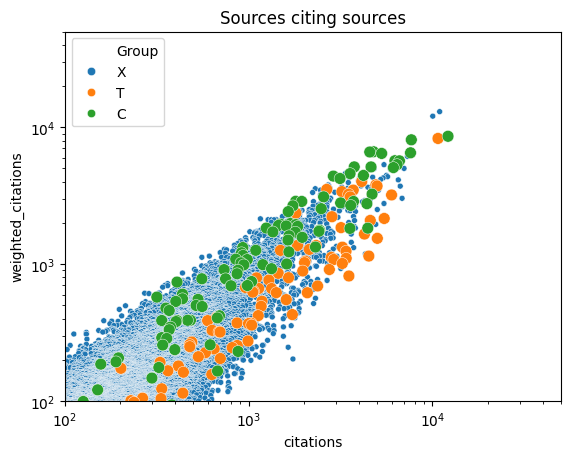

df.shape = (201, 5)
    weighted_citations  citations     ratio             author_name group
0           740.488757        408  1.814923          Philipp Strack     C
1           574.949868        317  1.813722         Olivier Gossner     C
2          2879.405536       1805  1.595239         Matteo Maggiori     C
3          2667.758047       1743  1.530555      Ralph S. J. Koijen     C
4          4398.654313       2894  1.519922        Matthew Gentzkow     C
5          2872.261388       1948  1.474467            Emi Nakamura     C
6          2419.550339       1645  1.470851         Parag A. Pathak     C
7          1835.876756       1249  1.469877          Jonathan Levin     C
8          6595.705739       4566  1.444526         Amy Finkelstein     C
9          1322.496095        930  1.422039          Yuliy Sannikov     C
10          782.495870        557  1.404840          Isaiah Andrews     C
11         6622.743977       4783  1.384642              Raj Chetty     C
12          604.68

In [54]:
if __name__ == "__main__":
    main()
    print("DONE!")